In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os, glob, shutil

basedir = '/data/srlab/AMP_collab/data/early_disease_synovium/'
xeniumdir = f'{basedir}/xenium'

dest_path = '/data/srlab/AMP_collab/data/early_disease_synovium/xenium'

In [63]:
tx = pd.read_parquet(f'/data/srlab/AMP_collab/data/early_disease_synovium//xenium/Xenium_RA-SYN-EDP1/Level_2/8073578284-02-02/transcripts.parquet')

In [64]:
cd3 = tx[tx.feature_name == 'CD3E']
cd3

,transcript_id,cell_id,overlaps_nucleus,feature_name,x_location,y_location,z_location,qv,fov_name,nucleus_distance,codeword_index,codeword_category,is_gene
150085,281595235973948,aajhnjjl-1,0,CD3E,476.890625,2339.406250,37.515625,40.00,E1,0.00000,4185,predesigned_gene,True
150086,281595236124505,aajhnjjl-1,1,CD3E,480.187500,2337.984375,37.421875,33.25,E1,0.00000,6050,predesigned_gene,True
150087,281595236360785,aajhnjjl-1,1,CD3E,480.015625,2340.828125,34.468750,40.00,E1,0.00000,6050,predesigned_gene,True
150088,281595235879057,aajhnjjl-1,1,CD3E,477.250000,2344.953125,37.750000,40.00,E1,0.00000,6123,predesigned_gene,True
150089,281595235879140,aajhnjjl-1,0,CD3E,481.796875,2338.343750,36.593750,40.00,E1,0.93750,6123,predesigned_gene,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
209672196,281805690968252,iadbbnil-1,1,CD3E,10065.078125,4652.250000,18.500000,40.00,H17,0.00000,6123,predesigned_gene,True
209672197,281805690970277,bbfgdfnn-1,0,CD3E,10147.640625,4563.187500,18.156250,40.00,H17,0.06250,6123,predesigned_gene,True
209672198,281805691985390,hahempbh-1,1,CD3E,10050.234375,4698.765625,15.937500,34.75,H17,0.00000,6123,predesigned_gene,True
209672199,281805692089976,hahempbh-1,1,CD3E,10046.921875,4696.453125,15.687500,40.00,H17,0.00000,6123,predesigned_gene,True


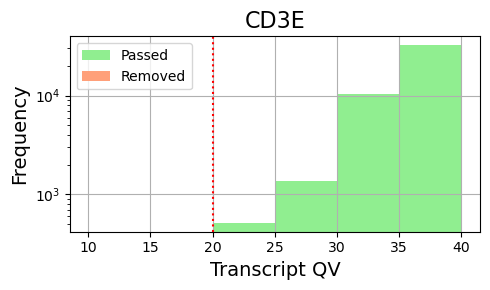

In [72]:
fig, ax = plt.subplots(figsize=(5, 3))
cd3.hist(column='qv', bins=[10, 15, 20, 25, 30, 35, 40], ax=ax)

# Recolor bars based on threshold
threshold = 20
colors = []
for patch in ax.patches:
    if patch.get_x() >= threshold:
        patch.set_facecolor('lightgreen')
    else:
        patch.set_facecolor('lightsalmon')  # light orange

# Add title
ax.set_title('CD3E', fontsize=16)
ax.set_xlabel('Transcript QV', fontsize=14)
ax.set_ylabel("Frequency", fontsize=14)
ax.set_yscale('log')
ax.axvline(x=20, color='red', linestyle='dotted')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='lightgreen', label='Passed'),
                   Patch(facecolor='lightsalmon', label='Removed')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [ ]:
metadata = pd.concat([
    pd.read_csv(f'{basedir}/Xenium_CTRL-SYN-EDP1_assay manifest.csv').assign(subset="CTRL-SYN-EDP1"),
    pd.read_csv(f'{basedir}/Xenium_RA-SYN-EDP1_assay manifest.csv').assign(subset="RA-SYN-EDP1"),
    pd.read_csv(f'{basedir}/Xenium_RA-SYN-EDP2_assay manifest.csv').assign(subset="RA-SYN-EDP2"),
    pd.read_csv(f'{basedir}/Xenium_PsD-SYN-EDP1_assay manifest.csv').assign(subset="PsD-SYN-EDP1"), 
    pd.read_csv(f'{basedir}/Xenium_RA-SYN-ARBITRATE_assay manifest.csv').assign(subset="RA-SYN-ARBITRATE")
]).set_index('Sample_ID')

In [44]:
# copy transcript parquet files into proper folders
for sid in metadata.index:#[metadata.index.str.contains('treatment')]:
    s = f'out/samples/{sid}'
    subset = metadata.loc[sid].subset
    
    # make folder for dest
    target_dir = f'{dest_path}/Xenium_{subset}/Level_2/{sid}'
    os.makedirs(target_dir, exist_ok=True)

    # copy transcripts.parquet file
    print(subset, f'{s}/transcripts_txqc_geneqc.parquet')
    shutil.copy(f'{s}/transcripts_txqc_geneqc.parquet', f'{target_dir}/transcripts.parquet')

CTRL-SYN-EDP1 out/samples/8073578341-02-02/transcripts_txqc_geneqc.parquet


PermissionError: [Errno 1] Operation not permitted: '/data/srlab/AMP_collab/data/early_disease_synovium/xenium/Xenium_CTRL-SYN-EDP1/Level_2/8073578341-02-02/transcripts.parquet'